# Message ID Overlap: IA vs NWA

Visualizes message-id overlap and reference coverage between the Internet Archive and Norwegian Web Archive.
Data is produced by `scripts/compare_ia_nwa_message_ids.py`.

In [6]:
import json
import matplotlib.pyplot as plt
from usenet_no.notebook_utils import venn2_fmt


def load(path):
    with open(path) as f:
        return json.load(f)


full = load("../data/ia_nwa_message_id_overlap.json")
filtered = load("../data/ia_nwa_message_id_overlap_date_filtered.json")

## Message ID overlap

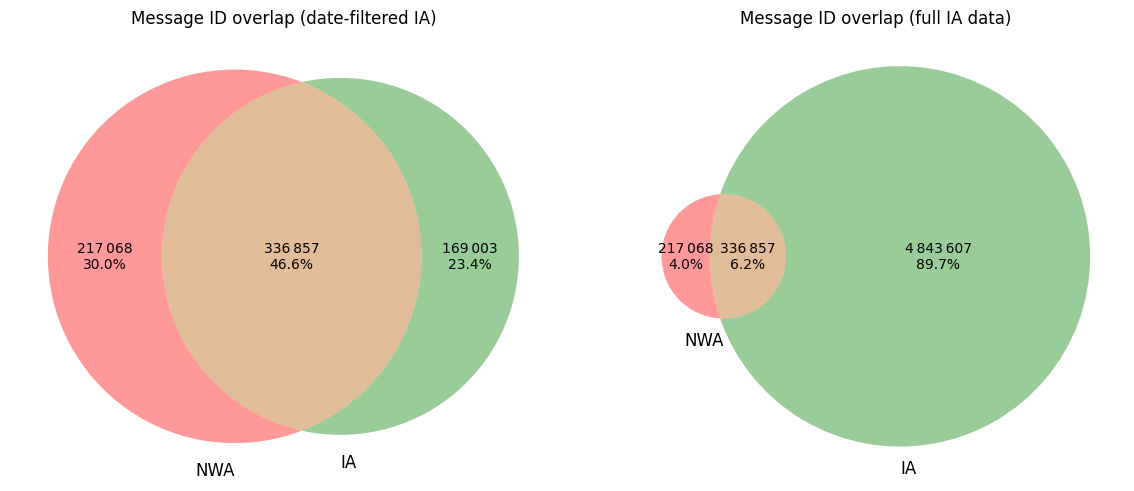

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in [
    (axes[0], filtered, "date-filtered IA"),
    (axes[1], full, "full IA data"),
]:
    venn2_fmt(
        subsets=(data["ids_nwa_only"], data["ids_ia_only"], data["ids_in_both"]),
        set_labels=("NWA", "IA"),
        ax=ax,
        show_pct=True,
    )
    ax.set_title(f"Message ID overlap ({title})")

plt.tight_layout()
plt.show()

## Cross-archive reference resolution

Messages referenced in one archive but missing from it — how many are covered by the other archive?

In [8]:
def fmt(n):
    return f"{n:,}".replace(",", " ")


for label, data in [("Full IA", full), ("IA date-filtered", filtered)]:
    ia_resolved = data["ia_refs_resolved_by_nwa"]
    ia_total = (
        ia_resolved + data["ghost_cited_by_ia_only"] + data["ghost_cited_by_both"]
    )
    nwa_resolved = data["nwa_refs_resolved_by_ia"]
    nwa_total = (
        nwa_resolved + data["ghost_cited_by_nwa_only"] + data["ghost_cited_by_both"]
    )
    print(f"{label}:")
    print(
        f"  IA refs resolved by NWA:  {fmt(ia_resolved)} of {fmt(ia_total)} ({ia_resolved / ia_total:.2%})"
    )
    print(
        f"  NWA refs resolved by IA:   {fmt(nwa_resolved)} of {fmt(nwa_total)} ({nwa_resolved / nwa_total:.2%})"
    )
    print()

Full IA:
  IA refs resolved by NWA:  27 246 of 207 277 (13.14%)
  NWA refs resolved by IA:   6 488 of 17 448 (37.18%)

IA date-filtered:
  IA refs resolved by NWA:  27 203 of 48 662 (55.90%)
  NWA refs resolved by IA:   6 488 of 17 448 (37.18%)



### Venn diagrams: outside-archive references vs resolved by other archive

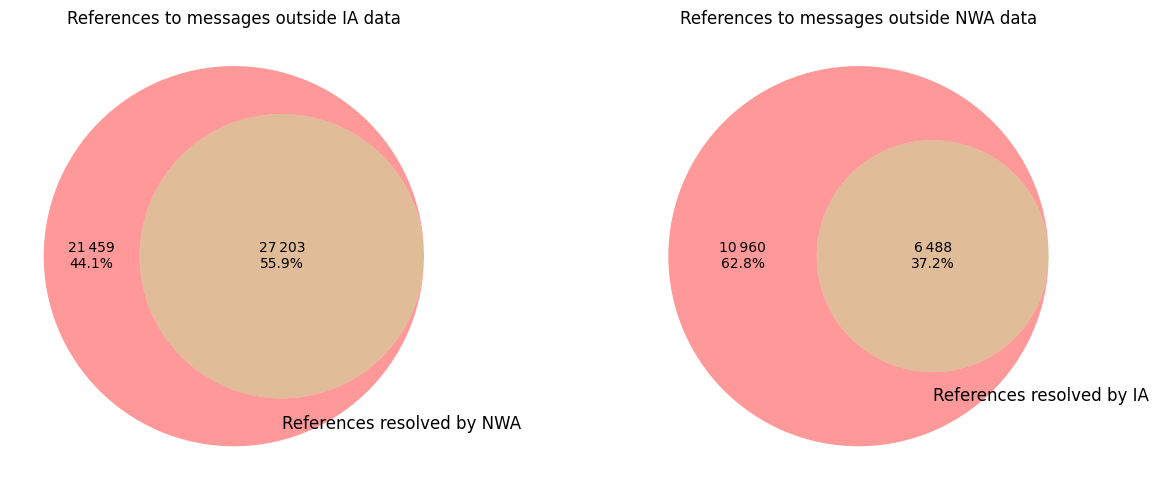

In [13]:
for label, data in [("IA date-filtered", filtered)]:
    ghost_ia = data["ghost_cited_by_ia_only"] + data["ghost_cited_by_both"]
    ghost_nwa = data["ghost_cited_by_nwa_only"] + data["ghost_cited_by_both"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, (archive, ghost, resolved, other) in zip(
        axes,
        [
            ("IA", ghost_ia, data["ia_refs_resolved_by_nwa"], "NWA"),
            ("NWA", ghost_nwa, data["nwa_refs_resolved_by_ia"], "IA"),
        ],
    ):
        venn2_fmt(
            subsets=(ghost, 0, resolved),
            set_labels=("", f"References resolved by {other}"),
            ax=ax,
            show_pct=True,
        )
        title = f"References to messages outside {archive} data"
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

## Ghost references

Messages cited in References headers but absent from both archives.
Partitioned by which archive(s) cite them.

In [10]:
for label, data in [("Full IA", full), ("IA date-filtered", filtered)]:
    print(f"{label}:")
    print(f"  Cited by IA only:  {fmt(data['ghost_cited_by_ia_only'])}")
    print(f"  Cited by NWA only: {fmt(data['ghost_cited_by_nwa_only'])}")
    print(f"  Cited by both:     {fmt(data['ghost_cited_by_both'])}")
    print()

Full IA:
  Cited by IA only:  174 262
  Cited by NWA only: 5 191
  Cited by both:     5 769

IA date-filtered:
  Cited by IA only:  15 691
  Cited by NWA only: 5 192
  Cited by both:     5 768

